In [1]:
import matplotlib.pyplot as plt
import numpy as np

from superfv.finite_volume_driver import interpolate_cell_centers, integrate_cell_averages
from superfv.bin._finite_volume_driver import update_fv_fluxes as update_fv_fluxes_cpp

In [2]:
N = 32
ng = 2
p = 2

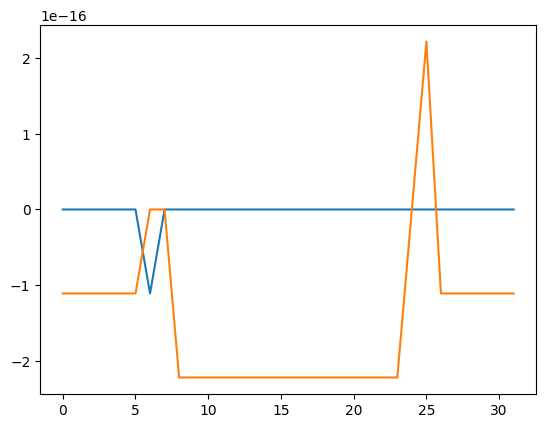

In [3]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, 1, 1))
_q_[:, _N_ // 4 : 3 * _N_ // 4, 0, 0] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)
_qav1_ = np.empty_like(_q_)
_qav2_ = np.empty_like(_q_)

interpolate_cell_centers(_q_, _qcc1_, ("x",), p)
integrate_cell_averages(_q_, _qav1_, ("x",), p)

update_fv_fluxes_cpp(_q_, _qav2_, _qcc2_, p, ng)

plt.plot(_qcc2_[0, ng:-ng, 0, 0] - _qcc1_[0, ng:-ng, 0, 0])
plt.plot(_qav2_[0, ng:-ng, 0, 0] - _qav1_[0, ng:-ng, 0, 0])

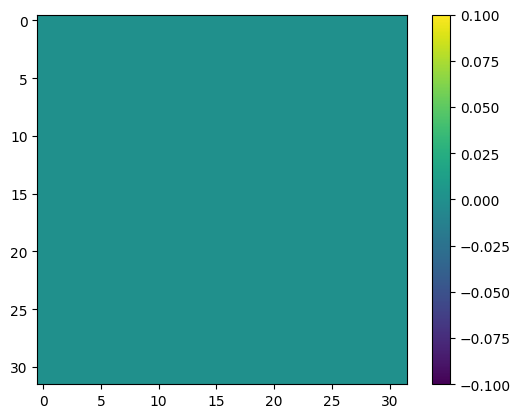

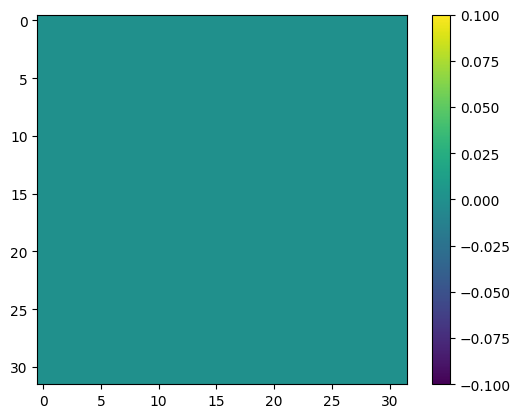

In [4]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, _N_, 1))
_q_[:, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4, 0] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)
_qav1_ = np.empty_like(_q_)
_qav2_ = np.empty_like(_q_)

interpolate_cell_centers(_q_, _qcc1_, ("x", "y"), p)
integrate_cell_averages(_q_, _qav1_, ("x", "y"), p)

update_fv_fluxes_cpp(_q_, _qav2_, _qcc2_, p, ng)

plt.imshow(_qcc2_[0, ng:-ng, ng:-ng, 0] - _qcc1_[0, ng:-ng, ng:-ng, 0])
plt.colorbar()
plt.show()

plt.imshow(_qav2_[0, ng:-ng, ng:-ng, 0] - _qav1_[0, ng:-ng, ng:-ng, 0])
plt.colorbar()
plt.show()

In [5]:
_N_ = N + 2 * ng
_q_ = np.ones((5, _N_, _N_, _N_))
_q_[:, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4, _N_ // 4 : 3 * _N_ // 4] = 2.0

_qcc1_ = np.empty_like(_q_)
_qcc2_ = np.empty_like(_q_)
_qav1_ = np.empty_like(_q_)
_qav2_ = np.empty_like(_q_)

interpolate_cell_centers(_q_, _qcc1_, ("x", "y", "z"), p)
integrate_cell_averages(_q_, _qav1_, ("x", "y", "z"), p)

update_fv_fluxes_cpp(_q_, _qav2_, _qcc2_, p, ng)

In [6]:
%%timeit
interpolate_cell_centers(_q_, _qcc1_, ("x", "y", "z"), p)
integrate_cell_averages(_q_, _qav1_, ("x", "y", "z"), p)

7.33 ms ± 508 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [7]:
%%timeit
update_fv_fluxes_cpp(_q_, _qav2_, _qcc2_, p, ng)

7.75 ms ± 79.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


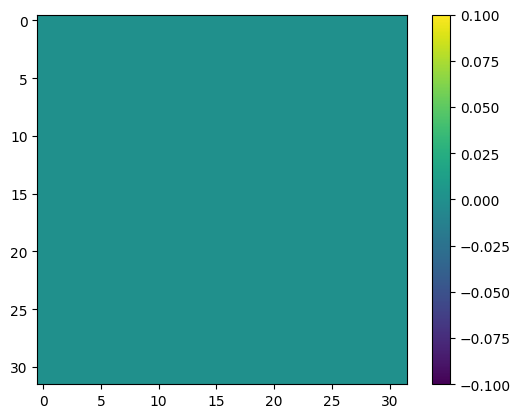

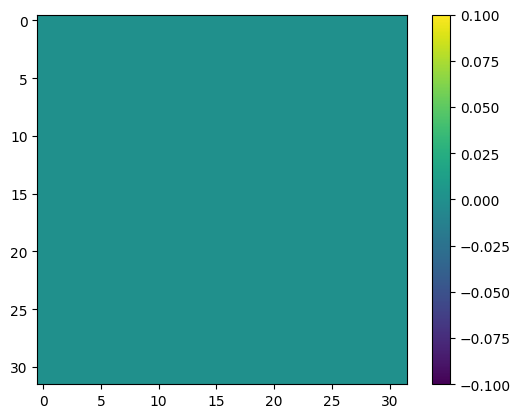

In [8]:
plt.imshow(_qcc2_[0, ng:-ng, ng:-ng, _N_ // 2] - _qcc1_[0, ng:-ng, ng:-ng, _N_ // 2])
plt.colorbar()
plt.show()

plt.imshow(_qav2_[0, ng:-ng, ng:-ng, _N_ // 2] - _qav1_[0, ng:-ng, ng:-ng, _N_ // 2])
plt.colorbar()
plt.show()